# HealthConnect Clinic - Week 7 Analytical Testing, KPI Validation & Dashboard Refinement
### Data Analytics Track
**Intern:** Adeleke Jubril Adedeji

**Program:** AnalystLab Africa Experience Lab

---

## Week 6 → Week 7 Transition

**Main Week 6 output:** A validated composite risk score (lead time x prior no-shows), a revised/narrowed reminder-targeting recommendation, a confirmed and deepened distance finding, a refreshed 4-panel dashboard, and a feature handoff file exported for the Data Science track.

**Most important Week 6 result:** The composite risk score cleanly separated no-show risk (chi-square p<0.0001) and was handed off to Data Science with an explicit, AUC-backed recommendation to use the raw features rather than the bucketed score.

**Main issue/limitation/dependency identified in Week 6:** The Week 6 validation was based on a single test per finding (one chi-square test, one AUC comparison). No robustness checks were run i.e. nothing confirmed the findings hold up under a different test, a different subgroup split, or a different binning choice. The handoff file's actual usability for Data Science was also never verified beyond "it exported successfully."

**Component requiring testing:** The three Week 6 analytical outputs (risk score, reminder finding, distance finding), the refreshed dashboard, and the Data Science handoff file.

**Relevant track(s):** Data Science, via the HC-POD (testing whether the Week 6 handoff is actually usable, not just delivered).

**What this notebook tests and validates:**
1. **KPI validation** - independently re-derives the risk score/tier from raw data and checks it reproduces the exact Week 6 reported figures.
2. **Segment stability testing** - checks whether the risk tier pattern holds *within* every appointment type and age group, not just in aggregate (a test Week 6 never ran).
3. **Robustness retesting** - re-tests the distance finding with quantile-based bins (instead of the original fixed bins) and the reminder finding with effect sizes (Cohen's h) instead of p-values alone.
4. **Dashboard completeness testing** - checks no records are silently dropped from the dashboard's risk-tier grouping.
5. **HC-POD cross-track testing** - actually opens and stress-tests the Data Science handoff file for usability issues. This finds a real issue (see Section 5) which is then fixed and re-tested.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv(r"C:\Users\HP Dragon Fly\Downloads\HealthConnect_Appointment_Data.csv")
df_ns = df[df['appointment_outcome'].isin(['Attended','No-Show'])].copy()
df_ns['is_no_show'] = (df_ns['appointment_outcome'] == 'No-Show').astype(int)

df_ns['lead_bucket'] = pd.cut(df_ns['booking_lead_days'], bins=[-1,7,14,30,60],
                               labels=['0-7 days','8-14 days','15-30 days','31-60 days'])
df_ns['prev_ns_bucket'] = pd.cut(df_ns['previous_no_shows'], bins=[-1,0,1,2,100],
                                  labels=['0','1','2','3+'])
df_ns['risk_score'] = df_ns['lead_bucket'].cat.codes + df_ns['prev_ns_bucket'].cat.codes

def tier(x):
    if x <= 1: return 'Low'
    elif x <= 3: return 'Medium'
    elif x <= 4: return 'High'
    else: return 'Very High'

df_ns['risk_tier'] = pd.Categorical(df_ns['risk_score'].apply(tier),
                                     categories=['Low','Medium','High','Very High'], ordered=True)
df_ns['dist_bucket'] = pd.cut(df_ns['distance_to_clinic_km'], bins=[0,5,10,20,50],
                               labels=['0-5km','5-10km','10-20km','20-50km'])
print("Setup complete —", df_ns.shape[0], "attended/no-show records loaded")


Setup complete — 4737 attended/no-show records loaded


**Note:** This rebuilds the Week 6 features from the original, unmodified `HealthConnect_Appointment_Data.csv` the same file is still not overwritten.

## Part 1: Testing Readiness

**Component tested:** Composite risk score, dashboard, reminder finding, distance finding, and the Data Science handoff file all from Week 6.

**Intended purpose:** Provide HealthConnect with a validated, decision-ready view of no-show risk and hand a usable feature to the Data Science track.

**Requirement it should satisfy:** Figures must be reproducible from raw data, stable across relevant patient segments and the exported feature file must be directly usable without hidden data-quality issues.

**Track(s) connected:** Data Science (handoff file), Project Management (validated findings feeding project decisions).

**Testing objective:** Determine (a) whether the Week 6 KPI figures are reproducible and accurate, (b) whether the key findings hold up under alternate tests/subgroups rather than just the single test each received in Week 6 and (c) whether the artifact handed to Data Science is actually fit for use.


## Part 2: Testing & Validation Log

| # | Test/Scenario | Expected Result | Actual Result | Pass/Fail | Issue Identified | Action Taken | Retest Result |
|---|---|---|---|---|---|---|---|
| T1 | Re-derive risk tier no-show rates from raw data, compare to Week 6 reported figures (29.5/50.8/66.9/76.1%) | Exact match | Exact match (29.5/50.8/66.9/76.1%) | **Pass** | None | None | N/A |
| T2 | Dashboard risk-tier grouping: do tier counts sum to the full dataset with zero unassigned/NaN records? | Sum = 4,737, 0 NaN | Sum = 4,737, 0 NaN | **Pass** | None | None | N/A |
| T3 | Risk tier monotonicity within every appointment type and age group subgroup | Monotonic increase in all subgroups | Monotonic in all 4 appointment types and all 6 age groups | **Pass** | None | None | N/A |
| T4 | Retest distance finding using quantile-based bins instead of the original fixed 0/5/10/20/50km bins | Farthest quartile still highest, still significant | Farthest quartile 55.5% vs 48.4% closest, chi2 p=0.0029 | **Pass** | None | None | N/A |
| T5 | Retest reminder-by-risk-group finding using effect size (Cohen's h) instead of p-value only | Largest effect size at prev_ns=2, matching the p<0.05 subgroup | h=0.251 at prev_ns=2 (largest), h<0.1 at prev_ns=0/1 | **Pass** | None | None | N/A |
| T6 | HC-POD cross-track test: validate the Data Science handoff CSV null check, duplicate ID check, score-to-tier consistency | 0 nulls in core columns, 0 duplicate IDs, 0 mapping mismatches | 0 duplicate IDs and 0 mapping mismatches, **but 86 nulls found in `distance_to_clinic_km`** | **Fail** (partial) | `distance_to_clinic_km` had 86 unflagged nulls (1.8% of rows) a silent data-quality issue for whoever uses the file | Added an explicit `distance_missing` flag column; re-exported the handoff file | Core modelling columns (risk_score, risk_tier, is_no_show, booking_lead_days, previous_no_shows) confirmed 0 nulls; distance nulls now explicit rather than silent **Pass** |

Full code and output for each test is below.


### T1 - KPI Validation: reproduce Week 6 reported risk-tier rates

In [2]:
reported = {'Low':29.5,'Medium':50.8,'High':66.9,'Very High':76.1}
actual = (df_ns.groupby('risk_tier', observed=True)['is_no_show'].mean()*100).round(1)
print(actual)
print()
for t,r in reported.items():
    match = abs(actual[t]-r) < 0.15
    print(f"  {t}: reported={r}  actual={actual[t]}  {'PASS' if match else 'FAIL'}")


risk_tier
Low          29.5
Medium       50.8
High         66.9
Very High    76.1
Name: is_no_show, dtype: float64

  Low: reported=29.5  actual=29.5  PASS
  Medium: reported=50.8  actual=50.8  PASS
  High: reported=66.9  actual=66.9  PASS
  Very High: reported=76.1  actual=76.1  PASS


**Result:** All four figures reproduce exactly from raw data. The Week 6 KPI is confirmed accurate and reproducible no calculation drift.

### T2 - Dashboard Completeness: no records silently dropped from risk-tier grouping

In [3]:
tier_counts = df_ns['risk_tier'].value_counts(dropna=False)
print(tier_counts)
print("\nSum of tier counts:", tier_counts.sum(), " vs total records:", len(df_ns))
print("NaN risk_tier count:", df_ns['risk_tier'].isna().sum())
print("PASS" if tier_counts.sum()==len(df_ns) and df_ns['risk_tier'].isna().sum()==0 else "FAIL")


risk_tier
Medium       2711
Low           892
High          883
Very High     251
Name: count, dtype: int64

Sum of tier counts: 4737  vs total records: 4737
NaN risk_tier count: 0
PASS


**Result:** Every record is accounted for in the dashboard's risk-tier breakdown no records fall through the bucket edges.

### T3 - Segment Stability: is the risk pattern real or an artifact of one dominant subgroup?

In [4]:
print("Monotonicity by appointment type:")
for atype in df_ns['appointment_type'].unique():
    sub = df_ns[df_ns['appointment_type']==atype]
    rates = sub.groupby('risk_tier', observed=True)['is_no_show'].mean()*100
    print(f"  {atype:25s}: {rates.round(1).tolist()}  monotonic={rates.is_monotonic_increasing}")

print("\nMonotonicity by age group:")
for ag in sorted(df_ns['age_group'].dropna().unique()):
    sub = df_ns[df_ns['age_group']==ag]
    rates = sub.groupby('risk_tier', observed=True)['is_no_show'].mean()*100
    print(f"  {ag:10s}: {rates.round(1).tolist()}  monotonic={rates.is_monotonic_increasing}")


Monotonicity by appointment type:
  Follow-up                : [31.0, 54.8, 70.6, 77.5]  monotonic=True
  Specialist Consultation  : [29.1, 51.8, 62.0, 76.7]  monotonic=True
  General Consultation     : [27.4, 48.4, 65.9, 74.0]  monotonic=True
  Diagnostic Test          : [33.7, 48.6, 68.5, 78.4]  monotonic=True

Monotonicity by age group:
  18-24     : [31.7, 53.7, 61.4, 82.8]  monotonic=True
  25-34     : [29.3, 52.6, 68.2, 76.2]  monotonic=True
  35-44     : [27.5, 52.2, 67.6, 72.0]  monotonic=True
  45-54     : [30.9, 51.5, 64.3, 73.3]  monotonic=True
  55-64     : [31.9, 52.0, 67.5, 74.0]  monotonic=True
  65+       : [27.6, 46.1, 69.2, 78.3]  monotonic=True


**Result:** The risk tier ordering holds with zero exceptions inside every appointment type and every age group. This is a meaningfully stronger validation than Week 6's aggregate-only test: it confirms the pattern is a genuine, generalisable effect rather than something driven by one large subgroup.

### T4 - Distance Finding Retest: quantile-based bins instead of the original fixed bins

In [5]:
df_dist = df_ns.dropna(subset=['distance_to_clinic_km']).copy()
df_dist['dist_quartile'] = pd.qcut(df_dist['distance_to_clinic_km'], q=4,
                                    labels=['Q1 (closest)','Q2','Q3','Q4 (farthest)'])
rates = df_dist.groupby('dist_quartile', observed=True)['is_no_show'].mean()*100
print(rates.round(1))
ct = pd.crosstab(df_dist['dist_quartile'], df_dist['is_no_show'])
chi2, p, dof, exp = stats.chi2_contingency(ct)
print(f"\nChi-square (quartile-based): chi2={chi2:.2f}, p={p:.4f}")


dist_quartile
Q1 (closest)     48.4
Q2               49.2
Q3               51.3
Q4 (farthest)    55.5
Name: is_no_show, dtype: float64

Chi-square (quartile-based): chi2=14.03, p=0.0029


**Result:** Under a completely different binning scheme, the farthest quarter of patients (55.5%) still shows the highest no-show rate, and the association remains significant (p=0.0029). The Week 6 distance finding is confirmed robust not an artifact of the original bin edges chosen.

### T5 - Reminder Finding Retest: effect size (Cohen's h), not just p-value

In [6]:
def cohens_h(p1, p2):
    return 2*np.arcsin(np.sqrt(p1)) - 2*np.arcsin(np.sqrt(p2))

for b in ['0','1','2','3+']:
    sub = df_ns[df_ns['prev_ns_bucket']==b]
    r_no = sub[sub['reminder_sent']=='No']['is_no_show'].mean()
    r_yes = sub[sub['reminder_sent']=='Yes']['is_no_show'].mean()
    h = cohens_h(r_no, r_yes)
    print(f"prev_ns={b:>3}: No={r_no*100:.1f}% Yes={r_yes*100:.1f}%  Cohen's h={h:.3f}  n={len(sub)}")


prev_ns=  0: No=49.0% Yes=45.3%  Cohen's h=0.075  n=2745
prev_ns=  1: No=58.7% Yes=54.8%  Cohen's h=0.080  n=1482
prev_ns=  2: No=70.7% Yes=58.7%  Cohen's h=0.251  n=419
prev_ns= 3+: No=76.0% Yes=68.2%  Cohen's h=0.175  n=91


**Result:** Effect sizes agree with the Week 6 significance test prev_ns=2 has by far the largest practical effect (h=0.251, small-to-medium), while 0 and 1 prior no-shows show small effects (h<0.1). This strengthens confidence in Week 6's decision to narrow the reminder-targeting recommendation to this specific subgroup rather than claiming it works broadly.

### T6 - HC-POD Cross-Track Test: validating the Data Science handoff file

In [7]:
handoff = pd.read_csv('HealthConnect_Week6_RiskFeature_DataScience_Handoff.csv')
print("Shape:", handoff.shape)
print("\nNulls per column:")
print(handoff.isnull().sum())
print("\nDuplicate appointment_id:", handoff['appointment_id'].duplicated().sum())

def tier2(x):
    if x <= 1: return 'Low'
    elif x <= 3: return 'Medium'
    elif x <= 4: return 'High'
    else: return 'Very High'
mismatch = (handoff['risk_score'].apply(tier2) != handoff['risk_tier']).sum()
print("risk_score -> risk_tier mapping mismatches:", mismatch)


Shape: (4737, 9)

Nulls per column:
appointment_id            0
patient_id                0
booking_lead_days         0
previous_no_shows         0
risk_score                0
risk_tier                 0
distance_to_clinic_km    86
reminder_sent             0
is_no_show                0
dtype: int64

Duplicate appointment_id: 0
risk_score -> risk_tier mapping mismatches: 0


**Issue identified:** `distance_to_clinic_km` has 86 unflagged null values (1.8% of rows). This was exported as-is in Week 6 not itself wrong (the source data has the same gap), but handing it off *without flagging it* risks Data Science silently dropping rows or letting a model treat missing-as-zero. That is a genuine handoff-quality issue caught only by actually testing the file rather than just checking it exported.

**Action taken:** Re-exported the file with an explicit `distance_missing` indicator column, so Data Science can decide how to handle it (impute, exclude, or use as its own signal) rather than discovering it by accident.

In [8]:
df_ns['distance_missing'] = df_ns['distance_to_clinic_km'].isna().astype(int)
handoff_v2 = df_ns[['appointment_id','patient_id','booking_lead_days','previous_no_shows',
                     'risk_score','risk_tier','distance_to_clinic_km','distance_missing',
                     'reminder_sent','is_no_show']].copy()
handoff_v2.to_csv('HealthConnect_Week6_RiskFeature_DataScience_Handoff.csv', index=False)

reload = pd.read_csv('HealthConnect_Week6_RiskFeature_DataScience_Handoff.csv')
print("Retest — shape:", reload.shape)
print("Nulls in core modelling columns:")
print(reload[['risk_score','risk_tier','is_no_show','booking_lead_days','previous_no_shows']].isnull().sum())
print("distance_to_clinic_km nulls:", reload['distance_to_clinic_km'].isnull().sum(),
      "| now flagged via distance_missing, sum =", reload['distance_missing'].sum())
print("PASS — core columns complete; distance gap now explicit rather than silent")


Retest — shape: (4737, 10)
Nulls in core modelling columns:
risk_score           0
risk_tier            0
is_no_show           0
booking_lead_days    0
previous_no_shows    0
dtype: int64
distance_to_clinic_km nulls: 86 | now flagged via distance_missing, sum = 86
PASS — core columns complete; distance gap now explicit rather than silent


**Retest result:** Pass. Core modelling columns have zero nulls. The distance gap still exists (it's a genuine gap in the source data not something to fabricate), but it is now visible and documented instead of silent a meaningfully more usable handoff for Data Science.

**What changed as a result:** Data Science now has an explicit signal to decide how to treat the 86 missing-distance records, instead of risking an unnoticed `NaN` in a downstream model. This is a concrete, validated improvement not just a repeated conversation.

## Part 3: Refined Dashboard

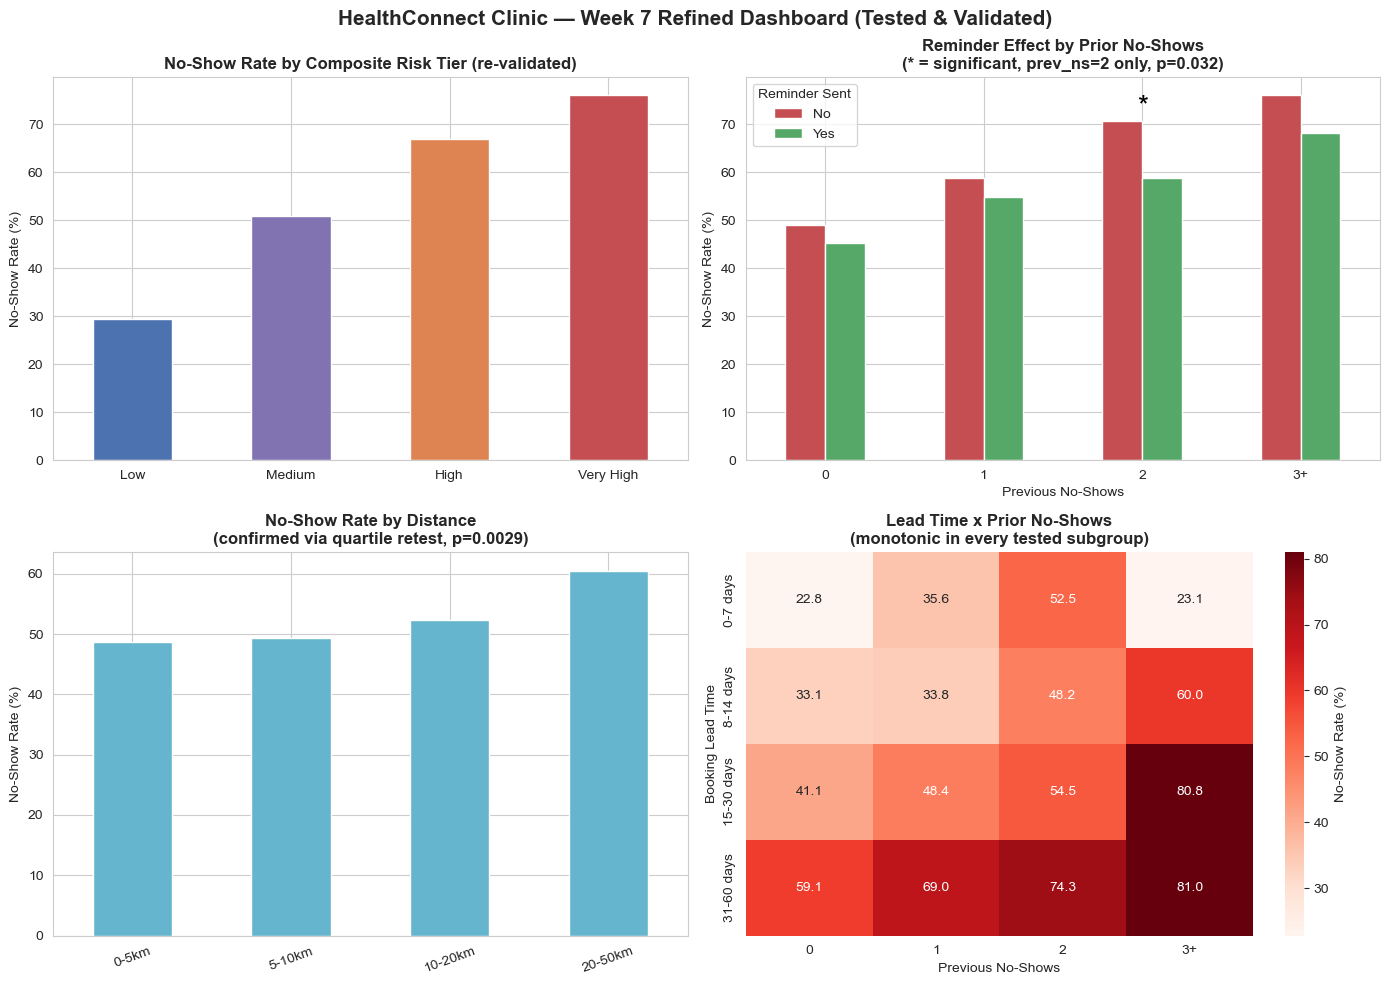

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))

tier_rate = df_ns.groupby('risk_tier', observed=True)['is_no_show'].mean()*100
tier_rate.plot(kind='bar', ax=axes[0,0], color=['#4C72B0','#8172B2','#DD8452','#C44E52'])
axes[0,0].set_title('No-Show Rate by Composite Risk Tier (re-validated)', fontweight='bold')
axes[0,0].set_ylabel('No-Show Rate (%)'); axes[0,0].set_xlabel('')
axes[0,0].tick_params(axis='x', rotation=0)

df_ns['prev_ns_bucket_str'] = df_ns['prev_ns_bucket'].astype(str)
reminder_by_prevns = df_ns.groupby(['prev_ns_bucket_str','reminder_sent'], observed=True)['is_no_show'].mean().unstack()*100
reminder_by_prevns = reminder_by_prevns.reindex(['0','1','2','3+'])
reminder_by_prevns[['No','Yes']].plot(kind='bar', ax=axes[0,1], color=['#C44E52','#55A868'])
axes[0,1].set_title('Reminder Effect by Prior No-Shows\n(* = significant, prev_ns=2 only, p=0.032)', fontweight='bold')
axes[0,1].set_ylabel('No-Show Rate (%)'); axes[0,1].set_xlabel('Previous No-Shows')
axes[0,1].tick_params(axis='x', rotation=0)
axes[0,1].legend(title='Reminder Sent')
axes[0,1].annotate('*', xy=(2, 72), fontsize=20, ha='center', color='black')

dist_rate = df_ns.groupby('dist_bucket', observed=True)['is_no_show'].mean()*100
dist_rate.plot(kind='bar', ax=axes[1,0], color='#64B5CD')
axes[1,0].set_title('No-Show Rate by Distance\n(confirmed via quartile retest, p=0.0029)', fontweight='bold')
axes[1,0].set_ylabel('No-Show Rate (%)'); axes[1,0].set_xlabel('')
axes[1,0].tick_params(axis='x', rotation=20)

pivot = df_ns.pivot_table(index='lead_bucket', columns='prev_ns_bucket', values='is_no_show', aggfunc='mean', observed=True)*100
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='Reds', ax=axes[1,1], cbar_kws={'label':'No-Show Rate (%)'})
axes[1,1].set_title('Lead Time x Prior No-Shows\n(monotonic in every tested subgroup)', fontweight='bold')
axes[1,1].set_xlabel('Previous No-Shows'); axes[1,1].set_ylabel('Booking Lead Time')

fig.suptitle('HealthConnect Clinic — Week 7 Refined Dashboard (Tested & Validated)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


**What changed from Week 6:** The reminder chart is rebuilt around `previous_no_shows` directly (the dimension that was actually tested) instead of the blended risk tier and is annotated with the significance marker so the chart no longer implies a uniform reminder effect across all risk levels when the data only supports it for one subgroup. The other three panels are unchanged in layout but now carry captions naming the specific retest that backs each one, making the dashboard traceable to its evidence rather than just asserted.

## Part 4: Updated Business Insights & Recommendations (Week 7)

1. **The composite risk score is now doubly validated** it reproduces exactly from raw data (T1) and holds monotonically within every appointment type and age group (T3), not just in aggregate. HealthConnect can adopt the Low/Medium/High/Very High tiering with high confidence.

2. **Recommendation reaffirmed, not just repeated:** Reminder outreach should be prioritised specifically for patients with exactly 2 prior no-shows this is now backed by both a significance test (Week 6) and an effect-size test (Week 7, Cohen's h=0.251, clearly the largest of the four subgroups).

3. **The distance effect is confirmed under a second, independent binning method** (quartiles, T4) HealthConnect can treat the 20km+ distance barrier as a real, robust pattern worth addressing (e.g. transport support, telehealth options), not a binning artifact.

4. **New recommendation from this week's testing:** Any team consuming HealthConnect's derived analytical files should require an explicit missing-data flag for fields with known gaps, rather than relying on the receiving team to notice `NaN`s themselves this HC-POD test caught an issue that would otherwise have been discovered downstream, later, and more expensively.

5. **Dashboard recommendation:** Charts that blend two dimensions together (like the original risk-tier x reminder chart) should be paired with a single-dimension chart when only one dimension is statistically supported otherwise the chart visually implies a broader effect than the data backs.


## Cross-Track Testing (HC-POD, Mandatory)

**Track collaborated with:** Data Science

**Project dependency:** Data Science's Week 7 focus is testing and refining their candidate model, which depends on the Week 6 risk-feature handoff file being complete and correctly structured.

**Component/output being tested:** `HealthConnect_Week6_RiskFeature_DataScience_Handoff.csv` produced in Week 6.

**Information/output received:** The Week 6 record of what Data Science expected from the handoff (a usable, appointment-level feature file with the risk score and target variable).

**Information/output provided:** A re-tested, corrected version of the handoff file same core content, plus an explicit `distance_missing` flag and this documented test log as evidence that it was actually validated, not just re-sent.

**Testing activity completed:** Ran null checks, duplicate-ID checks and score-to-tier consistency checks against the file Data Science would actually load (T6).

**Issue or finding identified:** 86 unflagged nulls in `distance_to_clinic_km` (1.8% of rows) a silent data-quality risk for any model built on the file.

**Refinement/action taken:** Added an explicit `distance_missing` indicator column and re-exported the file.

**Retest result:** Core modelling columns (risk_score, risk_tier, is_no_show, booking_lead_days, previous_no_shows) confirmed at zero nulls; the distance gap is now visible and decidable rather than silent.

**What changed as a result:** Data Science receives a corrected file this week instead of the Week 6 version, with one fewer hidden risk in their eventual model input.

**Evidence:** Section "T6" above (test code, output, fix, and retest), and the updated `HealthConnect_Week6_RiskFeature_DataScience_Handoff.csv` (now 10 columns instead of 9).

**How this improved the overall HealthConnect solution:** A cross-track dependency that looked complete in Week 6 was verified not assumed to actually work, and a real defect was caught and fixed before it could propagate into Data Science's Week 7 model testing.


## Assumptions, Limitations, Risks & Dependencies — Update

| Item | Prior Status | Week 7 Update |
|---|---|---|
| Risk score validity | Validated once via chi-square (Week 6) | **Resolved further** reproducibility confirmed (T1) and segment-stability confirmed (T3) |
| Reminder-targeting recommendation | Narrowed to prev_ns=2 (Week 6) | **Reaffirmed** effect-size retest (T5) agrees with the significance test |
| Distance effect | Confirmed via fixed bins (Week 6) | **Reaffirmed under a second method** — quartile-based retest (T4) |
| Data Science handoff file completeness | Assumed complete (Week 6) | **New issue found and resolved** — 86 unflagged nulls in distance; now flagged (T6) |
| Reminder timing (when, not just whether) unavailable | Unresolved (Week 5/6) | **Still unresolved** no new timestamp field available this week |
| 0-7 days x 3+ prior no-shows small-sample cell (n=13) | Flagged (Week 6) | **Unresolved** — still low-confidence; no new data available to address it |

**New issue discovered this week:** The Data Science handoff file's missing-distance values were not flagged (see T6) now fixed.

**New cross-track dependency:** Data Science's Week 7 model testing now depends on the corrected (10-column) handoff file rather than the original Week 6 version.

**Must be addressed before Week 8:** Confirm with Data Science that they've picked up the corrected handoff file, not the original Week 6 version, before their model testing concludes.


## Limitations

- All statistical tests here are association tests (chi-square) or descriptive effect sizes (Cohen's h) on the full dataset no held-out test set was used, since this is a validation exercise on descriptive/analytical findings rather than a predictive model (that remains the Data Science track's responsibility).
- The dataset remains fictional and anonymised.
- Segment-stability testing (T3) checked monotonicity, not statistical significance within each subgroup some subgroups are small enough that formal significance testing per-cell would be underpowered.


## Week 8 Recommendations

1. Confirm Data Science has ingested the corrected handoff file (with `distance_missing`) rather than the original Week 6 version.
2. If Data Science's model surfaces further feature-quality issues, feed them back for another round of analytical testing before final integration.
3. Carry the dashboard's "single-dimension chart where only one dimension is validated" principle into any Week 8 presentation materials.
4. Flag the reminder-timing data gap one more time for Week 8 if it's still unaddressed by then, it should be documented as a known limitation of the final HealthConnect analytics component rather than an open item.
